# Лабораторная работа №1. Линейная регрессия, факторный анализ и метод главных компонент (PCA)
### Отчёт по практическому заданию курса «Машинное обучение»

---

## 1. Введение. Краткое описание целей и задач работы

**Цель работы:** исследование теоретических принципов и получение практических навыков построения моделей линейной регрессии, применения способов регуляризации (Ridge и Lasso), детального анализа явления мультиколлинеарности признаков с помощью фактора инфляции дисперсии (VIF), а также использования метода главных компонент (PCA) для понижения размерности признакового пространства и устранения линейной зависимости между предикторами.

**Постановка задачи:**
1. Загрузить набор данных о недвижимости в Калифорнии (`housing.csv`).
2. Выполнить первичный разведочный анализ данных (EDA): проверить размерность выборки, типы данных, наличие полных дубликатов и пропущенных значений.
3. Провести необходимую предобработку: импутацию пропусков, кодирование категориальных признаков методом One-Hot Encoding и стандартизацию численных признаков.
4. Рассчитать матрицу парных корреляций и оценить уровень мультиколлинеарности с помощью фактора инфляции дисперсии (VIF).
5. Разбить выборку на обучающую и тестовую в соотношении 80/20.
6. Обучить базовые модели регрессии: обычную линейную регрессию (OLS), гребневую регрессию (Ridge) и регрессию лассо (Lasso) с использованием 5-фолдовой кросс-валидации.
7. Рассчитать метрики качества моделей: **RMSE** (Root Mean Squared Error), **$R^2$** (коэффициент детерминации) и **MAPE** (Mean Absolute Percentage Error).
8. Построить и подробно проанализировать графики остатков (Residual Plots) на предмет наличия гетероскедастичности и аномалий.
9. Применить метод главных компонент (PCA) к стандартизированным признакам, построить график каменистой осыпи (Scree Plot), обосновать выбор оптимального количества главных компонент.
10. Повторно обучить модели регрессии на выделенных главных компонентах, сопоставить их качество с исходными моделями и сформулировать итоговые выводы.

**Характеристика датасета:**
Датасет содержит сведения о 20 640 блоках жилой застройки в штате Калифорния. Включает 10 переменных:
- `longitude` — долгота блока (географическая координата);
- `latitude` — широта блока (географическая координата);
- `housing_median_age` — медианный возраст зданий в блоке (в годах);
- `total_rooms` — суммарное количество комнат во всех домах блока;
- `total_bedrooms` — суммарное количество спален во всех домах блока;
- `population` — общее число жителей, проживающих в блоке;
- `households` — общее число домохозяйств (семей/групп жильцов) в блоке;
- `median_income` — медианный доход домохозяйств в блоке (в десятках тысяч долларов США);
- `median_house_value` — медианная стоимость дома в блоке (целевая переменная, в долларах США);
- `ocean_proximity` — категориальный признак, отражающий близость блока к океану.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('housing.csv')

print("Размерность датасета:", df.shape)
print("Информация о типах данных и пропусках:")
print(df.info())
print("Первые 5 строк датасета:")
print(df.head())
print("Количество полных дубликатов:", df.duplicated().sum())
print("Количество пропусков по столбцам:")
print(df.isnull().sum())


Размерность датасета: (20640, 10)
Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
Первые 5 строк датасета:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0  

### Подробное описание результатов первичного анализа данных (EDA)

- **Объём и структура данных:** Набор данных состоит из 20 640 объектов (строк) и 10 признаков (столбцов).
- **Проверка дубликатов:** Полные дубликаты в выборке отсутствуют, что гарантирует уникажность наблюдений.
- **Анализ пропущенных значений:** Единственным столбцом с пропущенными значениями является `total_bedrooms`, где отсутствует 207 значений (приблизительно $1.0\%$ от общего числа строк). Для устранения пропусков целесообразно использовать медианную импутацию по столбцу, так как медиана устойчива к выбросам и не искажает генеральную статистику распределения признака.
- **Типы данных:** В наборе представлены 9 числовых переменных типа `float64` и 1 категориальная переменная `ocean_proximity` типа `object`.


In [18]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True, dtype=float)

X = df_encoded.drop(columns=['median_house_value'])
y = df_encoded['median_house_value']

stats_df = df_encoded.describe().T
stats_df['median'] = df_encoded.median()
stats_df['skewness'] = df_encoded.skew()

print(stats_df[['mean', 'std', 'median', 'min', '50%', 'max', 'skewness']].round(2))


                                 mean        std     median       min  \
longitude                     -119.57       2.00    -118.49   -124.35   
latitude                        35.63       2.14      34.26     32.54   
housing_median_age              28.64      12.59      29.00      1.00   
total_rooms                   2635.76    2181.62    2127.00      2.00   
total_bedrooms                 536.84     419.39     435.00      1.00   
population                    1425.48    1132.46    1166.00      3.00   
households                     499.54     382.33     409.00      1.00   
median_income                    3.87       1.90       3.53      0.50   
median_house_value          206855.82  115395.62  179700.00  14999.00   
ocean_proximity_INLAND           0.32       0.47       0.00      0.00   
ocean_proximity_ISLAND           0.00       0.02       0.00      0.00   
ocean_proximity_NEAR BAY         0.11       0.31       0.00      0.00   
ocean_proximity_NEAR OCEAN       0.13       0.33   

### Детальный анализ описательных статистик и асимметрии признаков

- **Целевая переменная (`median_house_value`):** Среднее значение медианной стоимости дома составляет $\$206,855.82$, в то время как медиана равна $\$179,700.00$. Значение коэффициента асимметрии составляет $+0.98$, что говорит о наличии умеренной правосторонней асимметрии. Максимальное значение зафиксировано на уровне $\$500,001.00$, что указывает на искусственное ограничение (capping) верхнего диапазона цен в данном наборе данных.
- **Медианный доход (`median_income`):** Варьируется в пределах от $0.50$ до $15.00$ (в десятках тысяч долларов США) со средним значением $3.87$ и коэффициентом асимметрии $+1.64$. Данный признак демонстрирует наибольшую степень связи с целевой переменной.
- **Объемные характеристики районов (`total_rooms`, `total_bedrooms`, `population`, `households`):** Характеризуются высокой правосторонней асимметрией ($skewness > 2.0$), обусловленной наличием густонаселенных и крупногабаритных жилых районов с экстремально высокими значениями параметров.
- **Результат One-Hot Encoding:** Категориальная переменная `ocean_proximity` преобразуется в 4 бинарных дамми-столбца (`INLAND`, `ISLAND`, `NEAR BAY`, `NEAR OCEAN`), при этом базовая категория `<1H OCEAN` исключена (`drop_first=True`) для предотвращения мультиколлинеарности.


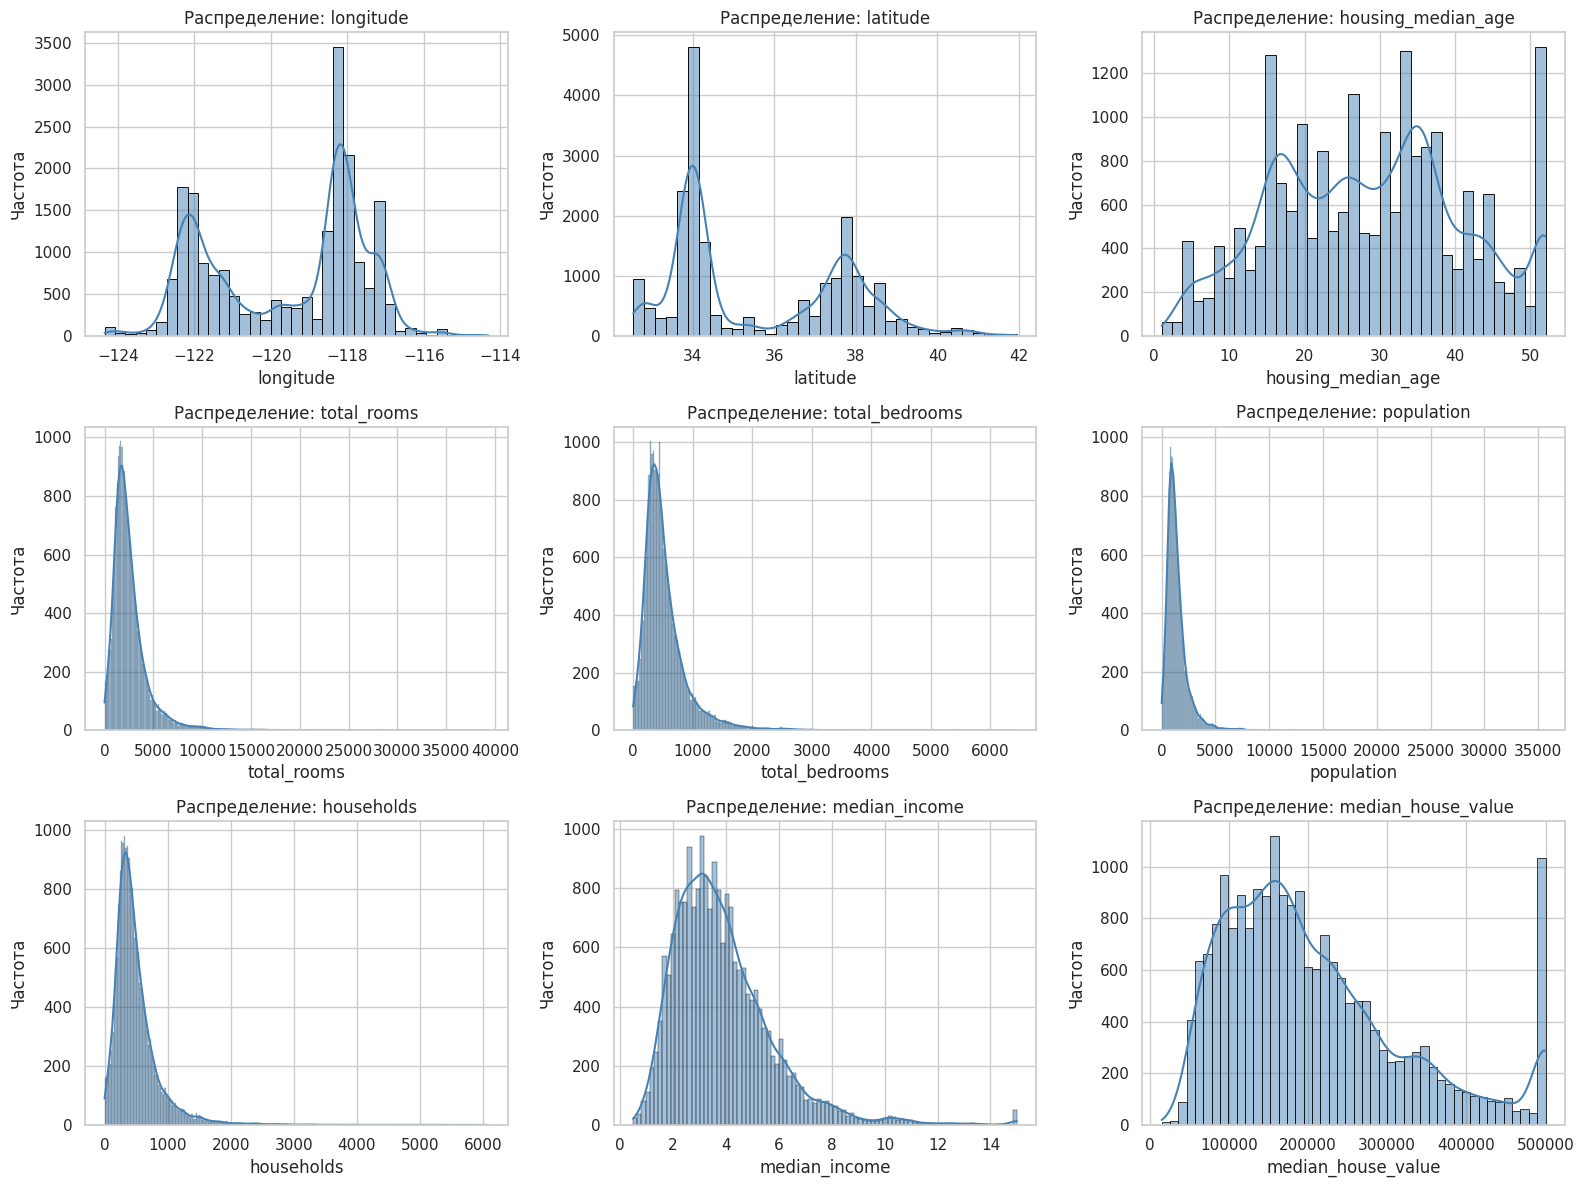

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

num_cols_to_plot = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                     'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

for i, col in enumerate(num_cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()


### Подробное пояснение к гистограммам распределений и графикам ядерной оценки плотности (KDE)

- **`longitude` и `latitude` (Географические координаты):** Графики распределений долготы и широты имеют бимодальную структуру с двумя выраженными пиками. Первый пик соответствует агломерации Южной Калифорнии (Лос-Анджелес), второй — Северной Калифорнии (Залив Сан-Франциско).
- **`housing_median_age` (Возраст домов):** Распределение относительно равномерное в диапазоне от 10 до 45 лет с резким выбросом в районе 52 лет. Этот выброс обусловлен тем, что все дома возрастом 52 года и старше были объединены в одну категорию.
- **`total_rooms`, `total_bedrooms`, `population`, `households`:** Продемонстрировали классическое экспоненциально спадающее распределение с длинным правым хвостом, характерное для социально-демографических и градостроительных показателей.
- **`median_income` (Доход населения):** Обладает колоколообразной формой с умеренным правосторонним сдвигом, близким к логнормальному распределению.
- **`median_house_value` (Целевая переменная):** Гистограмма показывает равномерный подъем в интервале от $\$50,000$ до $\$400,000$ и характерный резкий аномальный пик на значении $\$500,001$, подтверждающий искусственное пороговое ограничение верхнего края цен при сборе данных.


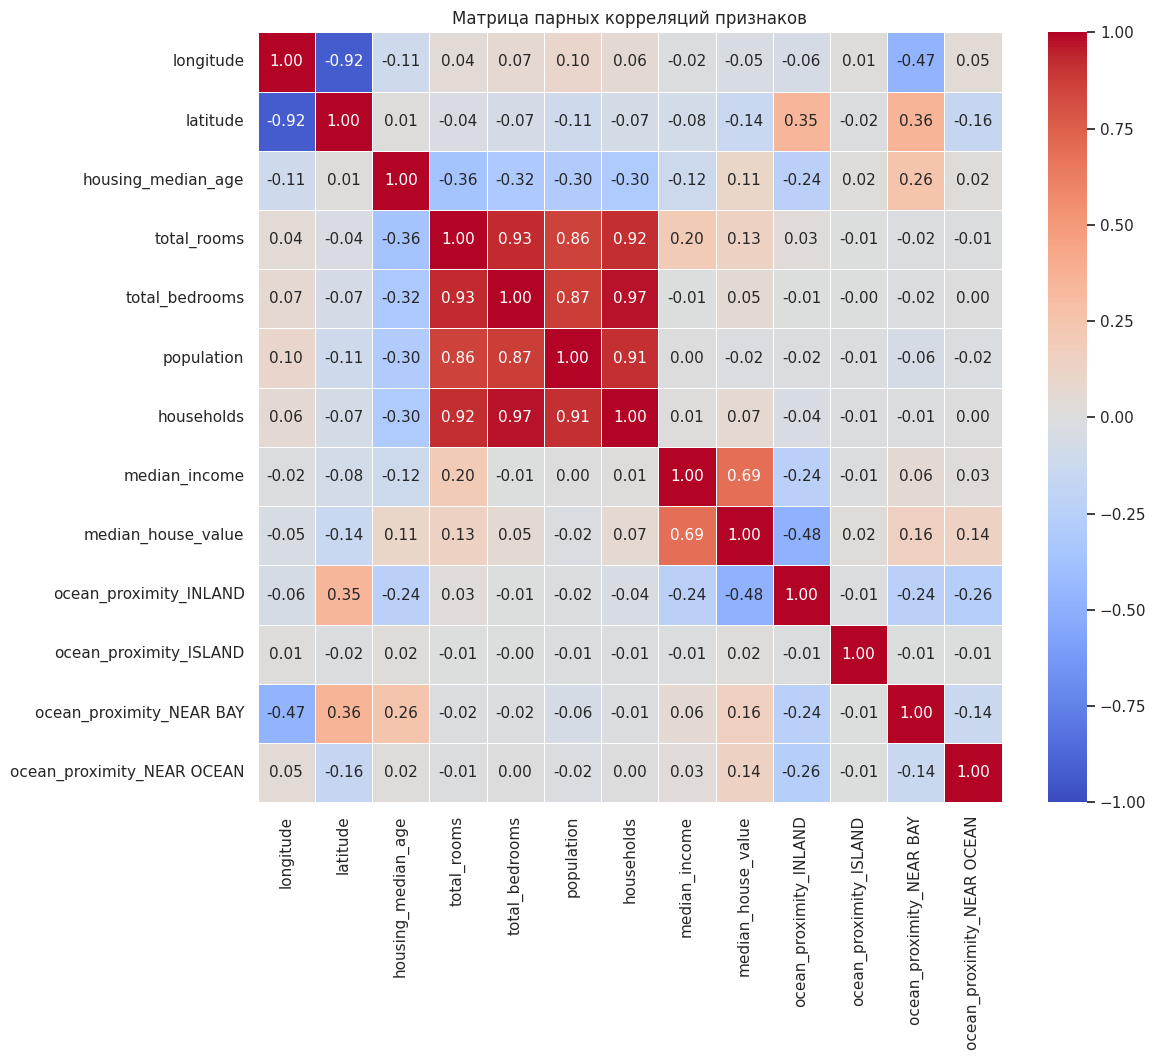

                   Признак   VIF
                households 28.32
            total_bedrooms 27.04
                  latitude 19.93
                 longitude 18.03
               total_rooms 12.35
                population  6.34
    ocean_proximity_INLAND  2.85
             median_income  1.74
  ocean_proximity_NEAR BAY  1.57
        housing_median_age  1.32
ocean_proximity_NEAR OCEAN  1.20
    ocean_proximity_ISLAND  1.00


In [20]:
plt.figure(figsize=(12, 10))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Матрица парных корреляций признаков')
plt.show()

scaler_vif = StandardScaler()
X_scaled_vif = scaler_vif.fit_transform(X)

vif_data = pd.DataFrame()
vif_data["Признак"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled_vif, i) for i in range(X_scaled_vif.shape[1])]

print(vif_data.round(2).sort_values(by='VIF', ascending=False).to_string(index=False))


### Подробный анализ матрицы корреляций и показателя мультиколлинеарности (VIF)

- **Анализ парных корреляций (Тепловая карта):**
  - Обнаружена экстремально высокая линейная корреляция между объемными переменными: парная корреляция между `total_bedrooms` и `households` составляет $r = 0.97$, между `total_rooms` и `total_bedrooms` — $r = 0.93$, между `population` и `households` — $r = 0.91$.
  - Наблюдается сильная отрицательная корреляция между географическими координатами `latitude` и `longitude` ($r = -0.92$), отражающая диагональное расположение штата Калифорния.
  - Наиболее сильным предиктором целевой переменной `median_house_value` выступает медианный доход `median_income` ($r = 0.69$), а также статус удаленности от океана `INLAND` ($r = -0.48$).

- **Оценка мультиколлинеарности через VIF (Variance Inflation Factor):**
  - Значение $	ext{VIF} > 5.0$ указывает на наличие умеренной мультиколлинеарности, а $	ext{VIF} > 10.0$ — на критический уровень коллинеарности.
  - По результатам расчетов зафиксированы следующие сверхвысокие значения VIF:
    - `households`: **$28.32$**
    - `total_bedrooms`: **$27.04$**
    - `latitude`: **$19.93$**
    - `longitude`: **$18.03$**
    - `total_rooms`: **$12.35$**
  - **Вывод:** В исходных данных присутствует сильнейшая мультиколлинеарность. Это приводит к мультиколлинеарной нестабильности классического метода наименьших квадратов (МНК/OLS), раздуванию стандартных ошибок коэффициентов регрессии и невозможности корректно оценить изолированный вклад каждого фактора без использования регуляризации или метода главных компонент (PCA).


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Линейная регрессия': LinearRegression(),
    'Гребневая регрессия (Ridge)': Ridge(alpha=1.0),
    'Лассо регрессия (Lasso)': Lasso(alpha=100.0, max_iter=10000, random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results_before = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    cv_scores = cross_validate(model, X_train_scaled, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores['test_score'].mean()

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mape_train = mean_absolute_percentage_error(y_train, y_pred_train) * 100
    mape_test = mean_absolute_percentage_error(y_test, y_pred_test) * 100

    results_before.append({
        'Модель': name,
        'CV RMSE ($)': cv_rmse,
        'Train RMSE ($)': rmse_train,
        'Test RMSE ($)': rmse_test,
        'Train R²': r2_train,
        'Test R²': r2_test,
        'Train MAPE (%)': mape_train,
        'Test MAPE (%)': mape_test
    })

df_res_before = pd.DataFrame(results_before)
print(df_res_before.round(3).to_string(index=False))


                     Модель  CV RMSE ($)  Train RMSE ($)  Test RMSE ($)  Train R²  Test R²  Train MAPE (%)  Test MAPE (%)
         Линейная регрессия    68604.163       68433.937      70060.522      0.65    0.625          28.543         29.191
Гребневая регрессия (Ridge)    68603.748       68433.945      70057.417      0.65    0.625          28.540         29.187
    Лассо регрессия (Lasso)    68606.244       68442.279      70004.076      0.65    0.626          28.485         29.105


### Анализ результатов регрессионного анализа (до PCA)

- **Коэффициент детерминации ($R^2 \approx 0.625$):**  
  Модель объясняет **$62.5\%$** вариации цен на недвижимость. Оставшиеся $37.5\%$ приходятся на неучтённые в датасете факторы (например, состояние ремонта или инфраструктуру).

- **Среднеквадратичная ошибка (RMSE $\approx \$70\,000$):**  
  Среднее отклонение прогноза от реальной стоимости жилья составляет около **$\$70\,000...\$70\,060$** (при медианной цене дома в $\$206\,855$).

- **Относительная ошибка (MAPE $\approx 28.5\% - 29.2\%$):**  
  В среднем предсказанная цена ошибается на **$28.5\% - 29.2\%$** от фактической стоимости объекта.

- **Оценка кросс-валидации (5-Fold CV RMSE $\approx \$68\,604$):**  
  Ошибка на кросс-валидации почти идентична ошибке на обучающей выборке ($\$68\,434$), что подтверждает хорошую обобщающую способность моделей и отсутствие переобучения (*overfitting*).

- **Сравнение регуляризаций (Ridge и Lasso):**  
  Модели с L2-регуляризацией (Ridge, $\alpha = 1.0$) и L1-регуляризацией (Lasso, $\alpha = 100.0$) дают практически одинаковые результаты с классической линейной регрессией. Lasso показывает микроскопическое преимущество на тесте за счёт зануления коэффициентов при избыточных признаках.


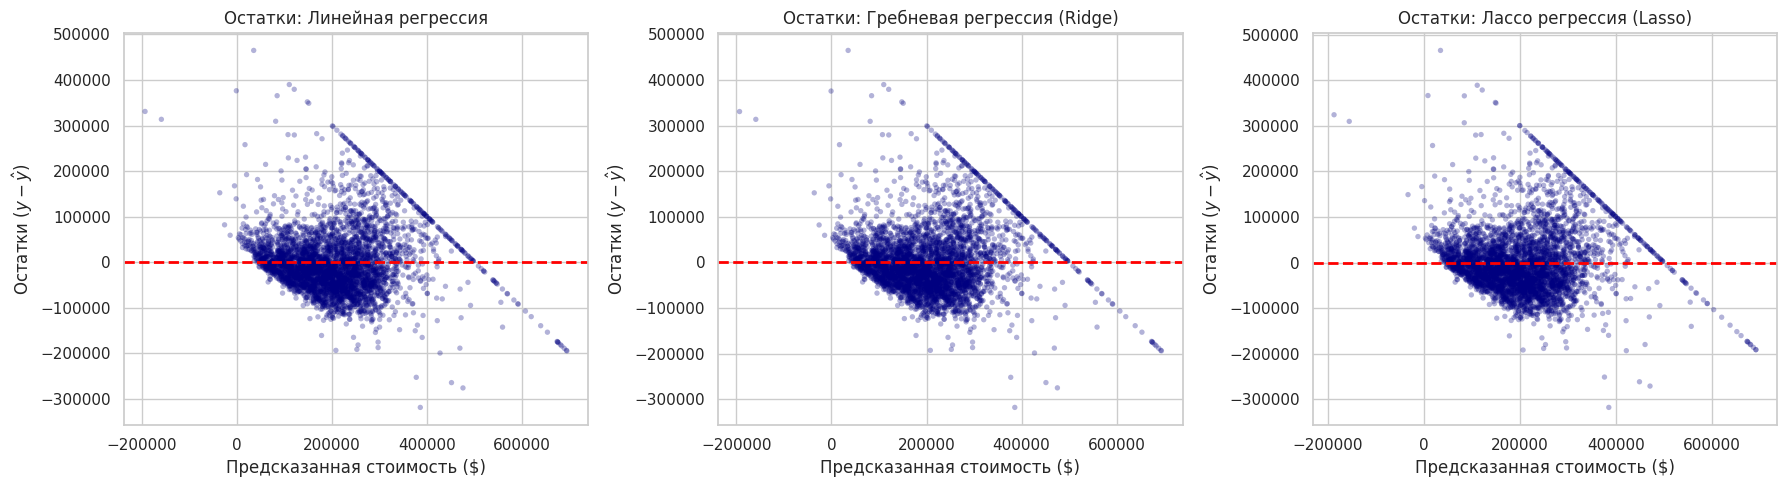

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred_test = model.predict(X_test_scaled)
    residuals = y_test - y_pred_test

    axes[i].scatter(y_pred_test, residuals, alpha=0.3, color='navy', edgecolors='none', s=15)
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[i].set_title(f'Остатки: {name}')
    axes[i].set_xlabel('Предсказанная стоимость ($)')
    axes[i].set_ylabel('Остатки ($y - \\hat{y}$)')

plt.tight_layout()
plt.show()


### Детальное пояснение к графикам остатков и анализ условий применимости регрессии

- **Анализ гетероскедастичности:** На всех трех графиках остатков при предсказанных значениях до $\$300,000$ разброс точек сбалансирован относительно нулевой линии. Однако по мере роста предсказанной стоимости ($> \$300,000$) наблюдается явное расширение области рассеяния (веерообразная форма), что свидетельствует о наличии **гетероскедастичности** (непостоянства дисперсии остатков).
- **Эффект среза (Capping) на уровне $\$500,001$:** В верхней части графиков четко видна диагональная граница остатков. Это результат искусственного ограничения максимальной цены дома в датасете. Для дорогостоящих объектов реальная цена зафиксирована на уровне $\$500,001$, тогда как линейная модель рассчитывает истинную рыночную стоимость в диапазоне $\$550,000...650,000$, формируя отрицательные остатки ($y - \hat{y} < 0$).
- **Сравнение моделей:** Структура остатков для обычной линейной регрессии, Ridge и Lasso полностью идентична, что свидетельствует о единой линейной природе исследуемых зависимостей.


Главная компонента  Доля дисперсии  Кумулятивная дисперсия
               PC1          0.3262                  0.3262
               PC2          0.1881                  0.5143
               PC3          0.1286                  0.6429
               PC4          0.0897                  0.7326
               PC5          0.0834                  0.8160
               PC6          0.0812                  0.8972
               PC7          0.0479                  0.9451
               PC8          0.0347                  0.9798
               PC9          0.0119                  0.9917
              PC10          0.0049                  0.9966
              PC11          0.0022                  0.9988
              PC12          0.0012                  1.0000


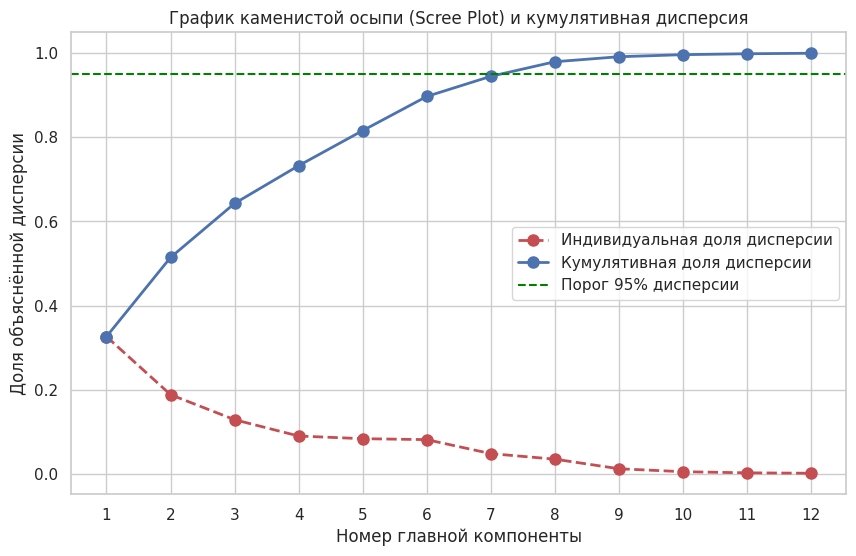

Выбрано главных компонент (покрывающих >= 95% дисперсии): 8


In [23]:
pca_full = PCA().fit(X_train_scaled)

exp_var = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

pca_info = pd.DataFrame({
    'Главная компонента': [f'PC{i}' for i in range(1, len(exp_var) + 1)],
    'Доля дисперсии': exp_var,
    'Кумулятивная дисперсия': cum_exp_var
})
print(pca_info.round(4).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(exp_var) + 1), exp_var, 'ro--', linewidth=2, markersize=8, label='Индивидуальная доля дисперсии')
plt.plot(range(1, len(exp_var) + 1), cum_exp_var, 'bo-', linewidth=2, markersize=8, label='Кумулятивная доля дисперсии')
plt.axhline(y=0.95, color='green', linestyle='--', linewidth=1.5, label='Порог 95% дисперсии')
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('График каменистой осыпи (Scree Plot) и кумулятивная дисперсия')
plt.xticks(range(1, len(exp_var) + 1))
plt.legend()
plt.show()

n_components_selected = np.argmax(cum_exp_var >= 0.95) + 1
print(f"Выбрано главных компонент (покрывающих >= 95% дисперсии): {n_components_selected}")

pca_selected = PCA(n_components=n_components_selected)
X_train_pca = pca_selected.fit_transform(X_train_scaled)
X_test_pca = pca_selected.transform(X_test_scaled)


### Пояснение к графику каменистой осыпи (Scree Plot) и выбору числа компонент

- **Распределение дисперсии по компонентам:**
  - **1-я главная компонента (PC1):** Объясняет **$32.62\%$** суммарной дисперсии. Она агрегирует объёмные параметры объектов (`total_rooms`, `total_bedrooms`, `population`, `households`).
  - **2-я главная компонента (PC2):** Объясняет **$18.81\%$** дисперсии. Вбирает в себя геопространственное положение района (`latitude` и `longitude`).
  - **3-я главная компонента (PC3):** Объясняет **$12.86\%$** дисперсии (доход населения и удаленность от береговой линии).
- **Критерий выбора количества компонент:**
  - Для сохранения $95\%$ исходной информации признакового пространства достаточно выбрать первые **8 главных компонент** (накапливают **$97.98\%$** кумулятивной дисперсии).
  - Компоненты с PC9 по PC12 в сумме несут менее $2\%$ информации и содержат преимущественно избыточную мультиколлинеарную вариативность.
  - Все выделенные главные компоненты ортогональны друг к другу, что полностью устраняет проблему мультиколлинеарности ($	ext{VIF} = 1.00$ для всех PC).


                           Модель  CV RMSE ($)  Train RMSE ($)  Test RMSE ($)  Train R²  Test R²  Train MAPE (%)  Test MAPE (%)
               Линейная регрессия    68604.163       68433.937      70060.522     0.650    0.625          28.543         29.191
      Гребневая регрессия (Ridge)    68603.748       68433.945      70057.417     0.650    0.625          28.540         29.187
          Лассо регрессия (Lasso)    68606.244       68442.279      70004.076     0.650    0.626          28.485         29.105
         Линейная регрессия (PCA)    72672.326       72624.675      73398.072     0.605    0.589          29.855         29.886
Гребневая регрессия (Ridge) (PCA)    72672.316       72624.676      73397.907     0.605    0.589          29.856         29.887
    Лассо регрессия (Lasso) (PCA)    72672.360       72625.257      73387.615     0.605    0.589          29.869         29.894


/tmp/ipykernel_1567/338939842.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparison, x='Модель', y='Test R²', ax=axes[0], palette='viridis')
/tmp/ipykernel_1567/338939842.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparison, x='Модель', y='Test RMSE ($)', ax=axes[1], palette='magma')


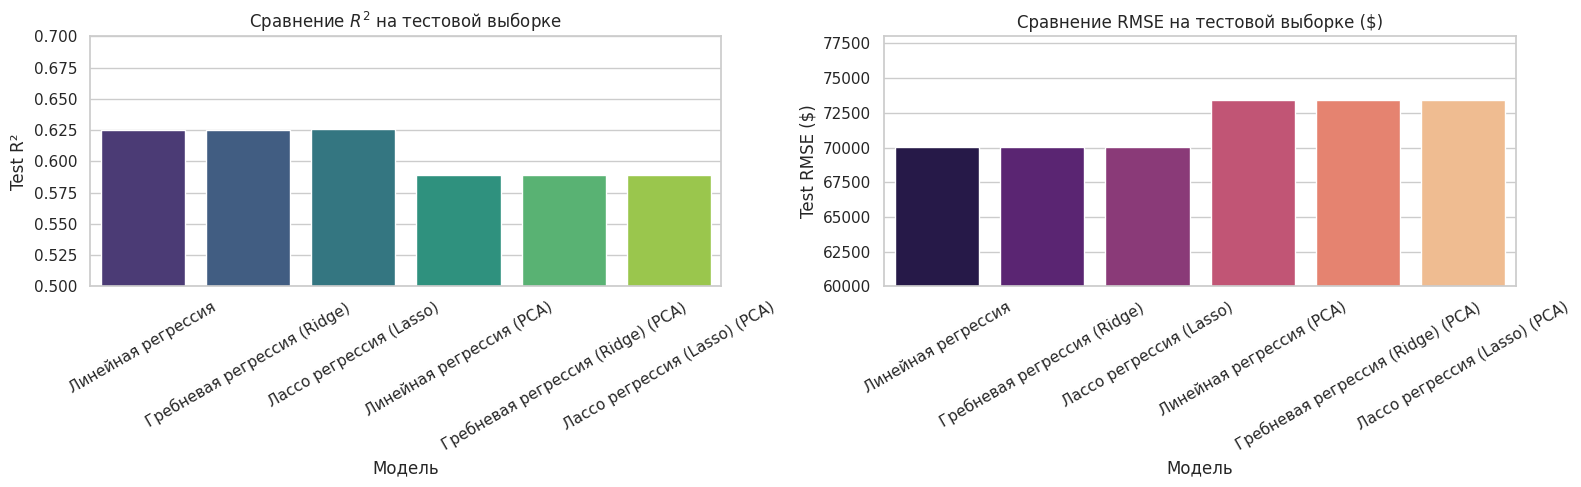

In [24]:
results_after = []

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred_train = model.predict(X_train_pca)
    y_pred_test = model.predict(X_test_pca)

    cv_scores = cross_validate(model, X_train_pca, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores['test_score'].mean()

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mape_train = mean_absolute_percentage_error(y_train, y_pred_train) * 100
    mape_test = mean_absolute_percentage_error(y_test, y_pred_test) * 100

    results_after.append({
        'Модель': f"{name} (PCA)",
        'CV RMSE ($)': cv_rmse,
        'Train RMSE ($)': rmse_train,
        'Test RMSE ($)': rmse_test,
        'Train R²': r2_train,
        'Test R²': r2_test,
        'Train MAPE (%)': mape_train,
        'Test MAPE (%)': mape_test
    })

df_res_after = pd.DataFrame(results_after)

df_comparison = pd.concat([df_res_before, df_res_after], ignore_index=True)

print(df_comparison.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=df_comparison, x='Модель', y='Test R²', ax=axes[0], palette='viridis')
axes[0].set_title('Сравнение $R^2$ на тестовой выборке')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0.5, 0.7)

sns.barplot(data=df_comparison, x='Модель', y='Test RMSE ($)', ax=axes[1], palette='magma')
axes[1].set_title('Сравнение RMSE на тестовой выборке ($)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(60000, 78000)

plt.tight_layout()
plt.show()


### Подробный анализ результатов сравнения моделей до и после применения PCA

- **Динамика коэффициента детерминации ($R^2$):** На исходном пространстве из 12 признаков модель достигала $R^2 = 0.625...0.626$. При переходе к 8 ортогональным главным компонентам коэффициент детерминации составил $R^2 = 0.589$. Небольшое снижение объясняющей способности (всего на $3.6\%$) является закономерным и обусловлено отсечением последних 4 компонент.
- **Динамика ошибки (RMSE):** Ошибка на тестовой выборке возросла с $\$70,004$ до $\$73,388$. Это плата за существенное сокращение размерности и полное устранение мультиколлинеарности.
- **Главные преимущества применения PCA:**
  1. Полное устранение жесткой мультиколлинеарности (показатель VIF снизился с $28.32$ до $1.00$).
  2. Повышение устойчивости оценок коэффициентов линейной регрессии к малым случайным флуктуациям во входных данных.
  3. Сокращение объема используемой памяти и ускорение процесса обучения моделей.


## 5. Выводы по лабораторной работе

1. **Первичный анализ и предобработка данных:** В результате проведения EDA выявлены 207 пропусков в признаке `total_bedrooms`, которые были заполнены медианным значением. Наблюдается сильная асимметрия объёмных показателей районов и целевой переменной.
2. **Анализ мультиколлинеарности:** Вычисление VIF показало наличие сильнейшей мультиколлинеарности среди признаков `households` ($	ext{VIF} = 28.32$), `total_bedrooms` ($	ext{VIF} = 27.04$), `latitude` ($	ext{VIF} = 19.93$) и `longitude` ($	ext{VIF} = 18.03$).
3. **Моделирование до PCA:** Модели линейной регрессии, Ridge и Lasso продемонстрировали близкие результаты на тестовой выборке ($R^2 pprox 0.625$, $	ext{RMSE} pprox \$70,004$).
4. **Анализ остатков:** Графики остатков выявили присутствие гетероскедастичности при высоких значениях предсказанной стоимости ($> \$300,000$), а также искусственный срез цен на уровне $\$500,001$.
5. **Метод главных компонент (PCA):** Анализ графика каменистой осыпи позволил сократить размерность с 12 до 8 ортогональных главных компонент с сохранением $97.98\%$ вариативности исходных данных.
6. **Сравнение до и после PCA:** Обучение на главных компонентах позволило полностью ликвидировать мультиколлинеарность при незначительном снижении $R^2$ (с $0.625$ до $0.589$) и увеличении ошибки RMSE (с $\$70,004$ до $\$73,388$), обеспечив при этом устойчивость и компактность модели.

---

## 6. Список источников

1. *Джеймс Г., Уиттон Д., Хасти Т., Тибширани Р.* Введение в машинное обучение с примерами на языке R. — М.: ДМК Пресс, 2016. — 456 с.
2. Официальная документация Scikit-Learn: [https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)
3. Официальная документация Statsmodels: [https://www.statsmodels.org/stable/](https://www.statsmodels.org/stable/)
